# Results of IMD grid fits

In [1]:
import os
import polars as pl
import numpy as np

from scipy.optimize import minimize
import statsmodels.api as sm  # for linear regression

import matplotlib.pyplot as plt

In [38]:
df_admissions_lines_very_many = pl.read_csv(os.path.join('outputs', 'line_fits_grid_ageonly_to_admissions_imd5_bounds.csv'))

In [39]:
df_admissions_lines_very_many.head()

start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0.8,1.0,0.0001,0.0007,0.0007,0.0007,0.007,-1.758813,0.0004,0.001,0.001,0.001,0.01,0.1081506
0,0.6,0.8,0.0001,0.0007,0.0007,0.0007,0.007,-2.245089,0.0004,0.001,0.001,0.001,0.01,-0.184314
0,0.4,0.6,0.0001,0.0007,0.0007,0.0007,0.007,-2.238987,0.0004,0.001,0.001,0.001,0.01,-0.286964
0,0.2,0.4,0.0001,0.0007,0.0007,0.0007,0.007,-2.900872,0.0004,0.001,0.0004,0.001,0.01,-0.809578
0,0.0,0.2,0.0001,0.0007,0.0007,0.0007,0.007,-4.019878,0.0004,0.001,0.0004,0.0004,0.01,-1.616865


In [40]:
quantile_min_list = sorted(df_admissions_lines_very_many['depriv_quantile_min'].unique())

quantile_min_list

[0.0, 0.2, 0.4, 0.6, 0.8]

For each quantile, of top X fits, what is the mean and std of the optimised coefficients?

In [41]:
cols_coeffs = [c for c in df_admissions_lines_very_many.columns if (('coeff' in c) & ('start' not in c))]

cols_coeffs

['coeff_age_less65',
 'coeff_age_65',
 'coeff_age_70',
 'coeff_age_75',
 'coeff_age_over80']

coeff_age_less65 7e-05 0.001


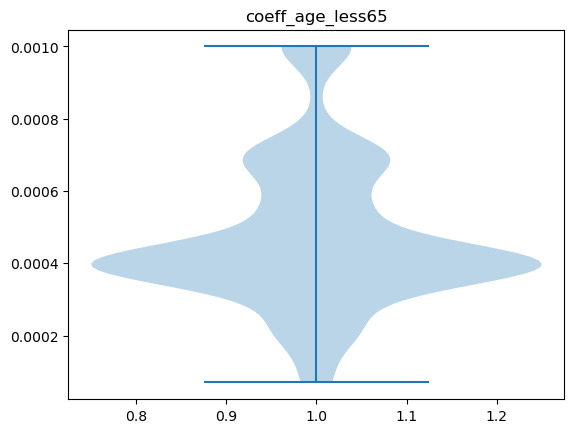

coeff_age_65 0.0004 0.007


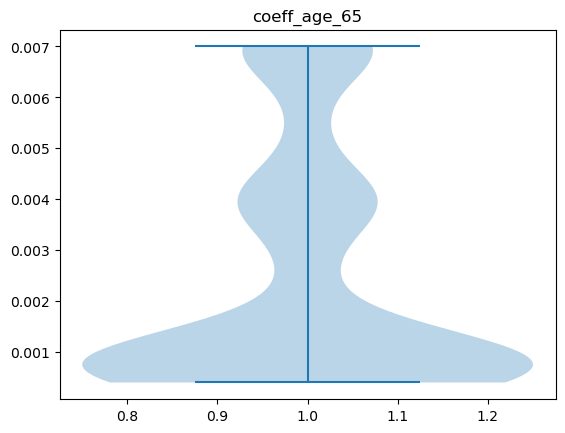

coeff_age_70 0.0004 0.007


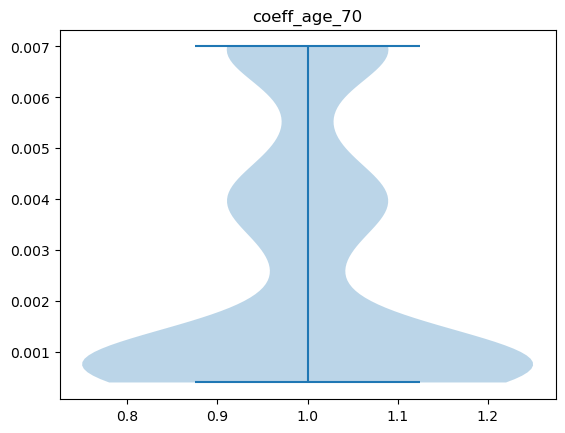

coeff_age_75 0.0004 0.007


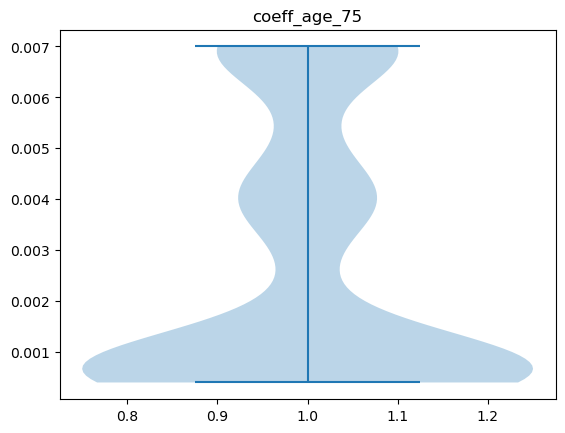

coeff_age_over80 0.0092211 0.02


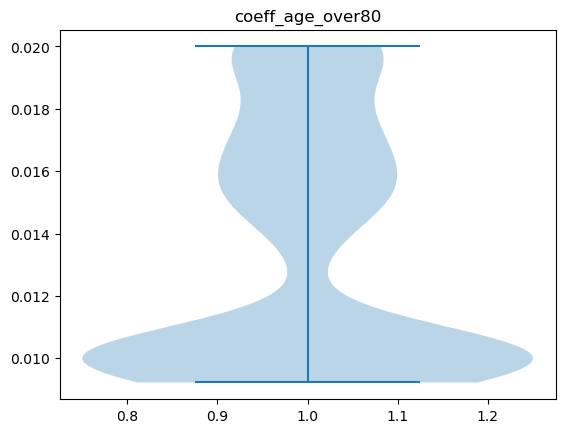

In [42]:
for col in cols_coeffs:
    print(
        col,
        df_admissions_lines_very_many[col].min(),
        df_admissions_lines_very_many[col].max()
    )
    plt.violinplot(df_admissions_lines_very_many[col])
    plt.title(col)
    plt.show()

In [43]:
start_coeff_cols = [c for c in df_admissions_lines_very_many.columns if 'start_coeff' in c]

coeff_start_values = sorted(list(set(df_admissions_lines_very_many[start_coeff_cols].to_numpy().flatten())))

coeff_start_values

[0.0001, 0.0004, 0.0007, 0.001, 0.004, 0.007, 0.01]

In [44]:
len(df_admissions_lines_very_many)

810

In [45]:
mask_start_coeffs = (
    df_admissions_lines_very_many['start_coeff_age_less65'].is_in([0.0001, 0.0004, 0.0007]) &
    df_admissions_lines_very_many['start_coeff_age_65'].is_in([0.0007, 0.001, 0.004]) &
    df_admissions_lines_very_many['start_coeff_age_70'].is_in([0.0007, 0.001, 0.004]) &
    df_admissions_lines_very_many['start_coeff_age_75'].is_in([0.0007, 0.001, 0.004]) &
    df_admissions_lines_very_many['start_coeff_age_over80'].is_in([0.007, 0.01])
)

df_admissions_lines_very_many = df_admissions_lines_very_many.filter(mask_start_coeffs)

In [46]:
len(df_admissions_lines_very_many)

810

Remove fits where any coefficient is exactly a boundary:

In [47]:
bounds_dict = {
    '0.0001': {'min': 7e-05, 'max': 0.0004},
    '0.0004': {'min': 0.0001, 'max': 0.0007},
    '0.0007': {'min': 0.0004, 'max': 0.001},
    '0.001': {'min': 0.0007, 'max': 0.004},
    '0.004': {'min': 0.001, 'max': 0.007},
    '0.007': {'min': 0.004, 'max': 0.01},
    '0.01': {'min': 0.009, 'max': 0.02}
}

bounds_list = []
for k, v in bounds_dict.items():
    for k2, v2 in v.items():
        if v2 in bounds_list:
            pass
        else:
            bounds_list.append(v2)

bounds_list

[7e-05, 0.0004, 0.0001, 0.0007, 0.001, 0.004, 0.007, 0.01, 0.009, 0.02]

In [48]:
mask_bounds = [
    df_admissions_lines_very_many[c].is_in(bounds_list) for c in cols_coeffs
    ]

mask_zero = mask_bounds[0]
for mask in mask_bounds[1:]:
    mask_zero = mask_zero | mask

In [49]:
df_admissions_lines_very_many['start_option'].filter(mask_zero)

start_option
i64
0
0
0
0
0
…
160
160
161


In [55]:
df_admissions_lines_very_many['start_option'].filter(mask_zero) == 0

start_option
bool
true
true
true
true
true
…
false
false
false


In [59]:
df_admissions_lines_very_many['start_option'].unique()

start_option
i64
0
1
2
3
4
…
157
158
159


Only keep options where the bounds are not hit for any IMD band:

In [61]:
start_options_to_keep = []

df_masked_start_options = df_admissions_lines_very_many['start_option'].filter(mask_zero)

for s in df_admissions_lines_very_many['start_option'].unique():
    n_here = len(df_masked_start_options.filter(df_masked_start_options == int(s)))
    if n_here == 0:
        start_options_to_keep.append(s)

start_options_to_keep

[101, 107]

In [63]:
df_admissions_lines_very_many = df_admissions_lines_very_many.filter(df_admissions_lines_very_many['start_option'].is_in(start_options_to_keep))

In [64]:
len(df_admissions_lines_very_many)

10

Round optimised coefficients to some significant figures:

In [65]:
df_admissions_lines_very_many.head()

start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
101,0.8,1.0,0.0004,0.004,0.001,0.004,0.01,0.578216,0.0001923,0.0029385,0.0014156,0.0023728,0.0152694,0.6270606
101,0.6,0.8,0.0004,0.004,0.001,0.004,0.01,0.473958,0.0003445,0.0010086,0.0008206,0.0062429,0.0149735,0.6126032
101,0.4,0.6,0.0004,0.004,0.001,0.004,0.01,0.396751,0.0003682,0.0033449,0.0007661,0.0026057,0.0170094,0.6438448
101,0.2,0.4,0.0004,0.004,0.001,0.004,0.01,0.082708,0.0004923,0.0052209,0.0010103,0.0029514,0.0159668,0.5820854
101,0.0,0.2,0.0004,0.004,0.001,0.004,0.01,-0.509055,0.0005494,0.0069225,0.0039841,0.0010117,0.0160872,0.4962223


Find highest combined R2:

In [66]:
start_options = df_admissions_lines_very_many['start_option'].unique()

In [67]:
dict_r2_combo = {}

for start_option in start_options:
    df_here = df_admissions_lines_very_many.filter(df_admissions_lines_very_many['start_option'] == start_option)
    r2_sum = df_here['rsquared'].sum()
    dict_r2_combo[str(start_option)] = r2_sum

In [68]:
df_r2_combo = pl.from_dict(dict_r2_combo).transpose(include_header=True)

In [69]:
df_r2_combo = df_r2_combo.rename({'column': 'start_option', 'column_0': 'r2_combo'})

In [70]:
df_r2_combo = df_r2_combo.sort('r2_combo', descending=True)

df_r2_combo

start_option,r2_combo
str,f64
"""101""",2.961816
"""107""",2.9570036


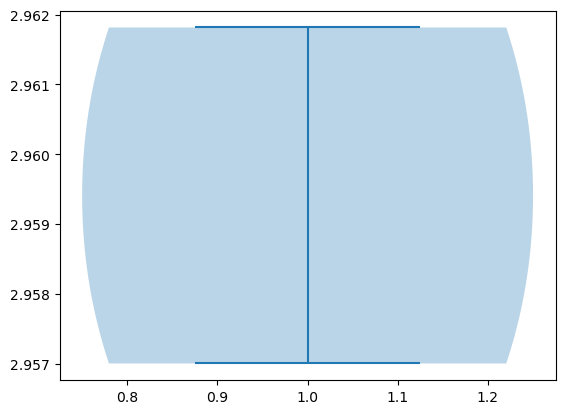

In [71]:
plt.violinplot(df_r2_combo['r2_combo'])
plt.show()

In [72]:
for start_option in df_r2_combo['start_option'][:10]:
    print(start_option)
    display(df_admissions_lines_very_many.filter(df_admissions_lines_very_many['start_option'] == start_option))

101


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
101,0.8,1.0,0.0004,0.004,0.001,0.004,0.01,0.578216,0.0001923,0.0029385,0.0014156,0.0023728,0.0152694,0.6270606
101,0.6,0.8,0.0004,0.004,0.001,0.004,0.01,0.473958,0.0003445,0.0010086,0.0008206,0.0062429,0.0149735,0.6126032
101,0.4,0.6,0.0004,0.004,0.001,0.004,0.01,0.396751,0.0003682,0.0033449,0.0007661,0.0026057,0.0170094,0.6438448
101,0.2,0.4,0.0004,0.004,0.001,0.004,0.01,0.082708,0.0004923,0.0052209,0.0010103,0.0029514,0.0159668,0.5820854
101,0.0,0.2,0.0004,0.004,0.001,0.004,0.01,-0.509055,0.0005494,0.0069225,0.0039841,0.0010117,0.0160872,0.4962223


107


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
107,0.8,1.0,0.0004,0.004,0.004,0.004,0.01,0.583549,0.0002254,0.0010754,0.0018612,0.0033977,0.0153865,0.6267682
107,0.6,0.8,0.0004,0.004,0.004,0.004,0.01,0.598182,0.0003472,0.0010037,0.0011469,0.0054938,0.0151559,0.6128349
107,0.4,0.6,0.0004,0.004,0.004,0.004,0.01,0.588812,0.0003796,0.002293,0.0010112,0.0051112,0.0158399,0.6436897
107,0.2,0.4,0.0004,0.004,0.004,0.004,0.01,0.367263,0.0004755,0.0040768,0.0030759,0.0034858,0.0147164,0.5797903
107,0.0,0.2,0.0004,0.004,0.004,0.004,0.01,-0.130848,0.0005436,0.0057224,0.0042974,0.0040165,0.0150141,0.4939205


Repeat with coeffs rounded:

In [80]:
for start_option in df_r2_combo['start_option'][:10]:
    print(start_option)
    df_here = df_admissions_lines_very_many.filter(df_admissions_lines_very_many['start_option'] == start_option)
    for col in cols_coeffs:
        df_here = df_here.with_columns(df_here[col].round_sig_figs(1))
    display(df_here)

101


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
101,0.8,1.0,0.0004,0.004,0.001,0.004,0.01,0.578216,0.0002,0.003,0.001,0.002,0.02,0.6270606
101,0.6,0.8,0.0004,0.004,0.001,0.004,0.01,0.473958,0.0003,0.001,0.0008,0.006,0.01,0.6126032
101,0.4,0.6,0.0004,0.004,0.001,0.004,0.01,0.396751,0.0004,0.003,0.0008,0.003,0.02,0.6438448
101,0.2,0.4,0.0004,0.004,0.001,0.004,0.01,0.082708,0.0005,0.005,0.001,0.003,0.02,0.5820854
101,0.0,0.2,0.0004,0.004,0.001,0.004,0.01,-0.509055,0.0005,0.007,0.004,0.001,0.02,0.4962223


107


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
107,0.8,1.0,0.0004,0.004,0.004,0.004,0.01,0.583549,0.0002,0.001,0.002,0.003,0.02,0.6267682
107,0.6,0.8,0.0004,0.004,0.004,0.004,0.01,0.598182,0.0003,0.001,0.001,0.005,0.02,0.6128349
107,0.4,0.6,0.0004,0.004,0.004,0.004,0.01,0.588812,0.0004,0.002,0.001,0.005,0.02,0.6436897
107,0.2,0.4,0.0004,0.004,0.004,0.004,0.01,0.367263,0.0005,0.004,0.003,0.003,0.01,0.5797903
107,0.0,0.2,0.0004,0.004,0.004,0.004,0.01,-0.130848,0.0005,0.006,0.004,0.004,0.02,0.4939205


Run grid:

Calculating:

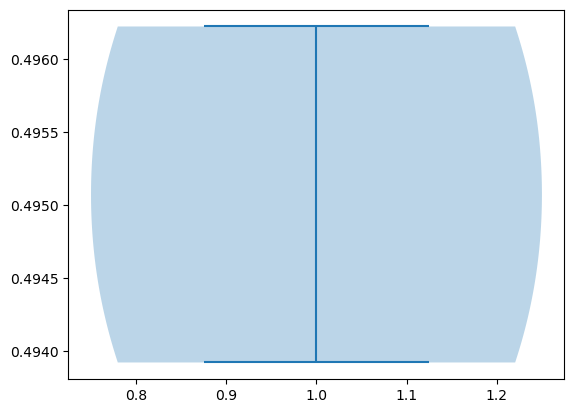

0.0005436 0.0005494 0.0005465
0.0057224 0.0069225 0.00632245
0.0039841 0.0042974 0.00414075
0.0010117 0.0040165 0.0025141
0.0150141 0.0160872 0.01555065


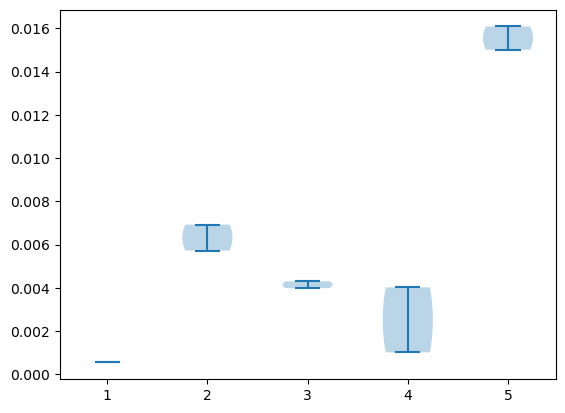

0.0 0.4962223 0.4939205 0.44660007
2 2


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
101,0.0,0.2,0.0004,0.004,0.001,0.004,0.01,-0.509055,0.0005494,0.0069225,0.0039841,0.0010117,0.0160872,0.4962223
107,0.0,0.2,0.0004,0.004,0.004,0.004,0.01,-0.130848,0.0005436,0.0057224,0.0042974,0.0040165,0.0150141,0.4939205


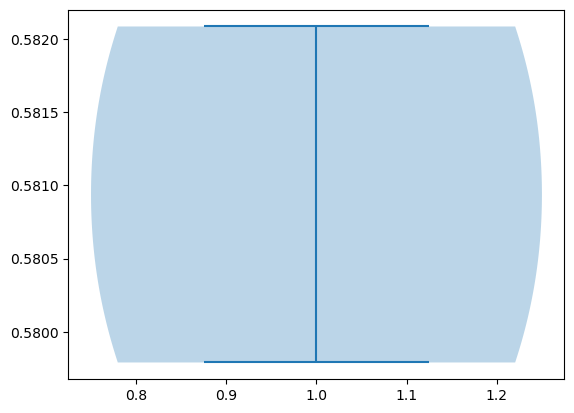

0.0004755 0.0004923 0.0004839
0.0040768 0.0052209 0.0046488499999999995
0.0010103 0.0030759 0.0020431
0.0029514 0.0034858 0.0032186
0.0147164 0.0159668 0.0153416


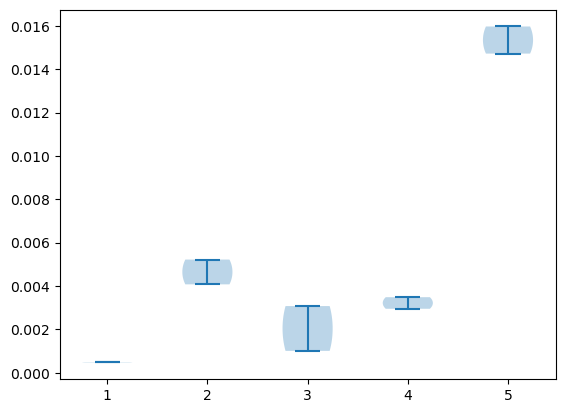

0.2 0.5820854 0.5797903 0.52387686
2 2


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
101,0.2,0.4,0.0004,0.004,0.001,0.004,0.01,0.082708,0.0004923,0.0052209,0.0010103,0.0029514,0.0159668,0.5820854
107,0.2,0.4,0.0004,0.004,0.004,0.004,0.01,0.367263,0.0004755,0.0040768,0.0030759,0.0034858,0.0147164,0.5797903


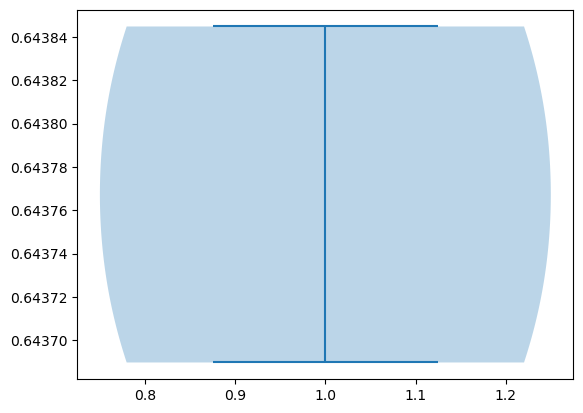

0.0003682 0.0003796 0.00037390000000000004
0.002293 0.0033449 0.0028189499999999998
0.0007661 0.0010112 0.00088865
0.0026057 0.0051112 0.00385845
0.0158399 0.0170094 0.01642465


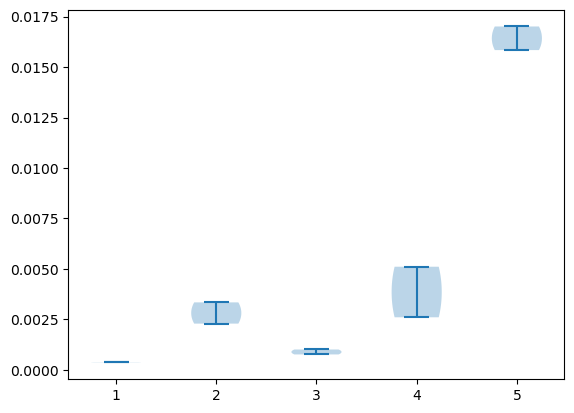

0.4 0.6438448 0.6436897 0.57946032
2 2


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
101,0.4,0.6,0.0004,0.004,0.001,0.004,0.01,0.396751,0.0003682,0.0033449,0.0007661,0.0026057,0.0170094,0.6438448
107,0.4,0.6,0.0004,0.004,0.004,0.004,0.01,0.588812,0.0003796,0.002293,0.0010112,0.0051112,0.0158399,0.6436897


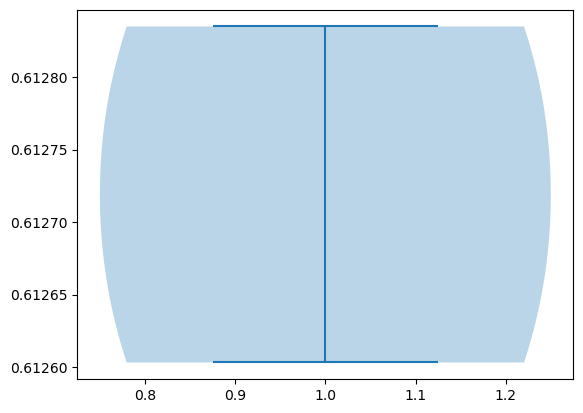

0.0003445 0.0003472 0.00034585
0.0010037 0.0010086 0.00100615
0.0008206 0.0011469 0.00098375
0.0054938 0.0062429 0.00586835
0.0149735 0.0151559 0.0150647


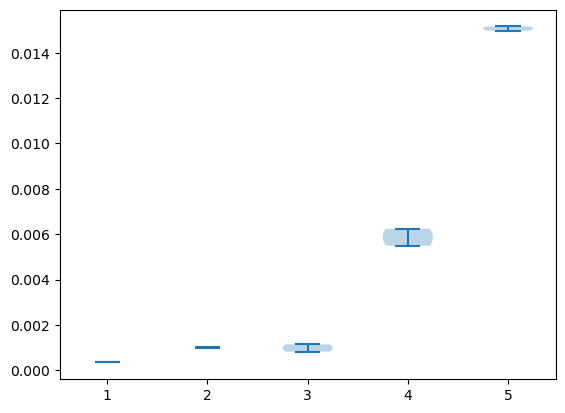

0.6 0.6128349 0.6126032 0.55155141
2 2


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
107,0.6,0.8,0.0004,0.004,0.004,0.004,0.01,0.598182,0.0003472,0.0010037,0.0011469,0.0054938,0.0151559,0.6128349
101,0.6,0.8,0.0004,0.004,0.001,0.004,0.01,0.473958,0.0003445,0.0010086,0.0008206,0.0062429,0.0149735,0.6126032


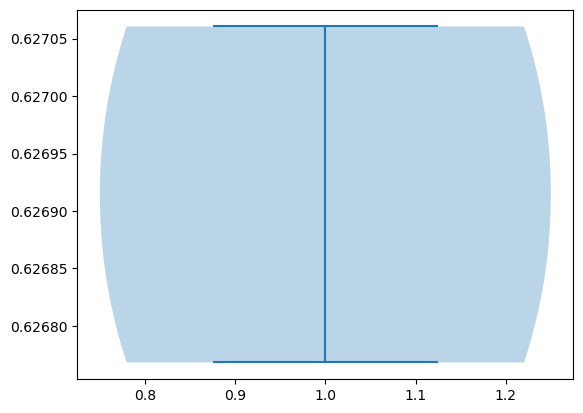

0.0001923 0.0002254 0.00020885
0.0010754 0.0029385 0.00200695
0.0014156 0.0018612 0.0016384
0.0023728 0.0033977 0.00288525
0.0152694 0.0153865 0.01532795


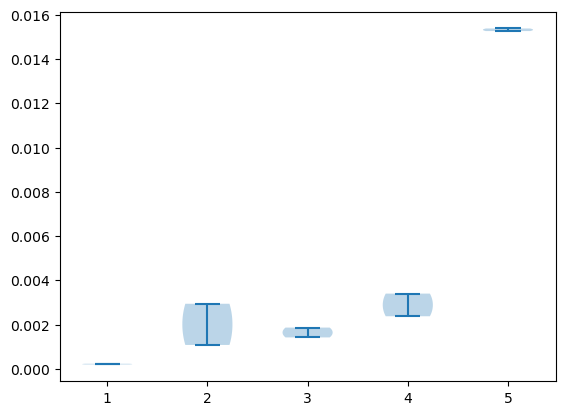

0.8 0.6270606 0.6267682 0.56435454
2 2


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
101,0.8,1.0,0.0004,0.004,0.001,0.004,0.01,0.578216,0.0001923,0.0029385,0.0014156,0.0023728,0.0152694,0.6270606
107,0.8,1.0,0.0004,0.004,0.004,0.004,0.01,0.583549,0.0002254,0.0010754,0.0018612,0.0033977,0.0153865,0.6267682


In [73]:
dict_results = {}

for q in quantile_min_list:
    print('\n')
    dict_results[q] = {}
    mask = df_admissions_lines_very_many['depriv_quantile_min'] == q
    df_here = df_admissions_lines_very_many.filter(mask).sort('rsquared', descending=True)
    r2_top = df_here['rsquared'].max()
    r2_bottom = df_here['rsquared'].min()

    plt.violinplot(df_here['rsquared'])
    plt.show()

    for col in cols_coeffs:
        print(df_here[col].min(), df_here[col].max(), df_here[col].median())
    plt.violinplot(df_here[cols_coeffs])
    plt.show()
    
    # Allow values within some tolerance of this max value:
    r2_low = r2_top * 0.90
    
    print(q, r2_top, r2_bottom, r2_low)
    

    df_q = pl.DataFrame()
    # mask_here = df_here['rsquared'] >= r2_low
    # df_h = df_here.filter(mask_here)
    df_h = df_here
    print(len(df_here), len(df_h))
    display(df_here)
    # for x in [10, 100, 1000, 10000]:
    # df_h = df_here[:x]
    means = df_h.mean()[cols_coeffs]
    stds = df_h.std()[cols_coeffs]

    # Add a column to mark how many fits went into these values.
    x = len(df_h)
    means = means.with_columns(pl.lit(x).alias('x'))
    # Rename std columns so later can combine stds and means
    # without repeating column names.
    stds = stds.rename(dict([(c, f'std_{c}') for c in stds.columns]))
    # Gather means and stds into one dataframe:
    means_stds = pl.concat((means, stds), how='horizontal')
    
    # Place this dataframe at the bottom of the existing dataframe:
    df_q = pl.concat((df_q, means_stds))

    dict_results[q] = df_q

Pick a value and see how many 

View results:

In [35]:
for q in quantile_min_list:
    print(q)
    display(dict_results[q])

0.0


coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,x,std_coeff_age_less65,std_coeff_age_65,std_coeff_age_70,std_coeff_age_75,std_coeff_age_over80
f64,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64
0.000572,0.004984,0.004383,0.003051,0.015749,12,0.000031,0.002721,0.002467,0.002269,0.002498


0.2


coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,x,std_coeff_age_less65,std_coeff_age_65,std_coeff_age_70,std_coeff_age_75,std_coeff_age_over80
f64,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64
0.000508,0.003072,0.00343,0.00269,0.015494,25,0.000036,0.002277,0.002427,0.002401,0.002404


0.4


coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,x,std_coeff_age_less65,std_coeff_age_65,std_coeff_age_70,std_coeff_age_75,std_coeff_age_over80
f64,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64
0.000394,0.002018,0.001842,0.00261,0.016833,40,0.000069,0.001682,0.001637,0.001909,0.002097


0.6


coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,x,std_coeff_age_less65,std_coeff_age_65,std_coeff_age_70,std_coeff_age_75,std_coeff_age_over80
f64,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64
0.000352,0.001351,0.002083,0.002662,0.015911,37,0.00006,0.00131,0.001745,0.002468,0.001949


0.8


coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,x,std_coeff_age_less65,std_coeff_age_65,std_coeff_age_70,std_coeff_age_75,std_coeff_age_over80
f64,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64
0.000256,0.001914,0.001841,0.002609,0.01483,44,0.000085,0.001644,0.001583,0.002119,0.001957


In [36]:
print(stop, here, please)

NameError: name 'stop' is not defined

In [ ]:
dict_results_old = dict_results

In [ ]:
for q in quantile_min_list:
    print(q)
    display(dict_results[q])

## Fine grid results

In [8]:
df_coeffs_grid = pl.read_csv(os.path.join('outputs', 'line_fits_grid_ageonly_to_admissions_imd5_postopt.csv'))

In [9]:
df_coeffs_grid

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64
23040,0.8,1.0,0.0001,0.0007,0.0006,0.0007,0.012,-0.319585
23040,0.6,0.8,0.0001,0.0007,0.0006,0.0007,0.012,-0.727782
23040,0.4,0.6,0.0001,0.0007,0.0006,0.0007,0.012,-0.883591
23040,0.2,0.4,0.0001,0.0007,0.0006,0.0007,0.012,-1.567636
23040,0.0,0.2,0.0001,0.0007,0.0006,0.0007,0.012,-2.689707
…,…,…,…,…,…,…,…,…
103679,0.8,1.0,0.0007,0.009,0.006,0.009,0.019,-6.686296
103679,0.6,0.8,0.0007,0.009,0.006,0.009,0.019,-5.244426
103679,0.4,0.6,0.0007,0.009,0.006,0.009,0.019,-3.361456


In [10]:
len(df_coeffs_grid)

403200

In [11]:
quantile_min_list = df_coeffs_grid['depriv_quantile_min'].unique().to_numpy()

quantile_min_list

array([0. , 0.2, 0.4, 0.6, 0.8])

Find how good R2 is compared with max available:

In [12]:
dict_quantile_max_r2 = {}

for q in quantile_min_list:
    df_here = df_coeffs_grid.filter(df_coeffs_grid['depriv_quantile_min'] == q)
    dict_quantile_max_r2[q] = df_here['rsquared'].max()

dict_quantile_max_r2

{0.0: 0.4999427005171354,
 0.2: 0.5847549383781983,
 0.4: 0.6454713431891492,
 0.6: 0.6151629147758857,
 0.8: 0.6282635223174148}

In [13]:
# Make columns for the results with a placeholder value:
df_coeffs_grid = df_coeffs_grid.with_columns(pl.lit(0).alias('rsquared_prop'))

for q in quantile_min_list:
    mask = df_coeffs_grid['depriv_quantile_min'] == q
    props = df_coeffs_grid['rsquared'] / dict_quantile_max_r2[q]
    
    df_coeffs_grid = df_coeffs_grid.with_columns(
        pl.when((mask))
        .then(props)         # replace with bin min
        .otherwise(pl.col('rsquared_prop'))  # otherwise keep the existing value
        .name.keep()
    )

In [14]:
df_coeffs_grid.sort('rsquared')

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
103679,0.8,1.0,0.0007,0.009,0.006,0.009,0.019,-6.686296,-10.642502
103671,0.8,1.0,0.0007,0.009,0.006,0.008,0.019,-6.263173,-9.969023
102719,0.8,1.0,0.0007,0.008,0.006,0.009,0.019,-6.160585,-9.805734
103583,0.8,1.0,0.0007,0.009,0.005,0.009,0.019,-6.113756,-9.731196
103678,0.8,1.0,0.0007,0.009,0.006,0.009,0.018,-6.077356,-9.673259
…,…,…,…,…,…,…,…,…,…
61604,0.4,0.6,0.0004,0.002,0.0007,0.006,0.016,0.645308,0.999747
61508,0.4,0.6,0.0004,0.002,0.0006,0.006,0.016,0.645334,0.999788
61877,0.4,0.6,0.0004,0.002,0.001,0.004,0.017,0.645439,0.99995


Find highest combined R2:

In [15]:
start_options = df_coeffs_grid['start_option'].unique()

In [16]:
dict_r2_combo = {}

for start_option in start_options:
    df_here = df_coeffs_grid.filter(df_coeffs_grid['start_option'] == start_option)
    r2_sum = df_here['rsquared'].sum()
    dict_r2_combo[str(start_option)] = r2_sum

In [17]:
df_r2_combo = pl.from_dict(dict_r2_combo).transpose(include_header=True)

In [18]:
df_r2_combo = df_r2_combo.rename({'column': 'start_option', 'column_0': 'r2_combo'})

In [19]:
df_r2_combo = df_r2_combo.sort('r2_combo', descending=True)

df_r2_combo

start_option,r2_combo
str,f64
"""88609""",2.420933
"""88441""",2.420918
"""88521""",2.420902
"""88529""",2.420854
"""88433""",2.420793
…,…
"""103678""",-15.979263
"""103583""",-16.01851
"""102719""",-16.094492


Add a column for a measure of how good this R2 combo is compared with the best:

In [20]:
df_r2_combo = df_r2_combo.with_columns((pl.col('r2_combo') / pl.col('r2_combo').max()).alias('r2_combo_prop'))

In [21]:
df_r2_combo

start_option,r2_combo,r2_combo_prop
str,f64,f64
"""88609""",2.420933,1.0
"""88441""",2.420918,0.999994
"""88521""",2.420902,0.999987
"""88529""",2.420854,0.999967
"""88433""",2.420793,0.999942
…,…,…
"""103678""",-15.979263,-6.600458
"""103583""",-16.01851,-6.616669
"""102719""",-16.094492,-6.648054


How many R2 combo are within some tolerance of the best value?

In [22]:
dict_r2_props = {}

for p in [0.9, 0.95, 0.99, 0.995, 0.999]:
    df_here = df_r2_combo.filter(df_r2_combo['r2_combo_prop'] > (df_r2_combo['r2_combo_prop'].max() * p))
    dict_r2_props[p] = len(df_here)

In [23]:
dict_r2_props

{0.9: 9538, 0.95: 4276, 0.99: 464, 0.995: 161, 0.999: 26}

In [24]:
# Change column type to integer to match imported grid results:
df_r2_combo = df_r2_combo.with_columns(pl.col('start_option').cast(pl.Int64, strict=False))

In [25]:
df_coeffs_grid = df_coeffs_grid.join(df_r2_combo, left_on='start_option', right_on='start_option', how='left')

In [26]:
df_coeffs_grid.head()

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
23040,0.8,1.0,0.0001,0.0007,0.0006,0.0007,0.012,-0.319585,-0.508681,-6.188302,-2.556164
23040,0.6,0.8,0.0001,0.0007,0.0006,0.0007,0.012,-0.727782,-1.183072,-6.188302,-2.556164
23040,0.4,0.6,0.0001,0.0007,0.0006,0.0007,0.012,-0.883591,-1.368908,-6.188302,-2.556164
23040,0.2,0.4,0.0001,0.0007,0.0006,0.0007,0.012,-1.567636,-2.680843,-6.188302,-2.556164
23040,0.0,0.2,0.0001,0.0007,0.0006,0.0007,0.012,-2.689707,-5.380031,-6.188302,-2.556164


In [27]:
df_coeffs_grid.sort('r2_combo', descending=True)

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
88609,0.8,1.0,0.0006,0.006,0.0009,0.0007,0.013,0.457485,0.728174,2.420933,1.0
88609,0.6,0.8,0.0006,0.006,0.0009,0.0007,0.013,0.568328,0.923866,2.420933,1.0
88609,0.4,0.6,0.0006,0.006,0.0009,0.0007,0.013,0.616075,0.954457,2.420933,1.0
88609,0.2,0.4,0.0006,0.006,0.0009,0.0007,0.013,0.526956,0.901158,2.420933,1.0
88609,0.0,0.2,0.0006,0.006,0.0009,0.0007,0.013,0.252088,0.504234,2.420933,1.0
…,…,…,…,…,…,…,…,…,…,…,…
103679,0.8,1.0,0.0007,0.009,0.006,0.009,0.019,-6.686296,-10.642502,-17.864601,-7.379223
103679,0.6,0.8,0.0007,0.009,0.006,0.009,0.019,-5.244426,-8.525264,-17.864601,-7.379223
103679,0.4,0.6,0.0007,0.009,0.006,0.009,0.019,-3.361456,-5.207754,-17.864601,-7.379223


In [28]:
df_coeffs_grid.sort('rsquared', descending=True)

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
62637,0.4,0.6,0.0004,0.003,0.0008,0.003,0.017,0.645471,1.0,2.214173,0.914595
62733,0.4,0.6,0.0004,0.003,0.0009,0.003,0.017,0.645456,0.999976,2.214007,0.914526
61877,0.4,0.6,0.0004,0.002,0.001,0.004,0.017,0.645439,0.99995,2.185989,0.902953
61508,0.4,0.6,0.0004,0.002,0.0006,0.006,0.016,0.645334,0.999788,2.184692,0.902418
61604,0.4,0.6,0.0004,0.002,0.0007,0.006,0.016,0.645308,0.999747,2.184632,0.902393
…,…,…,…,…,…,…,…,…,…,…,…
103678,0.8,1.0,0.0007,0.009,0.006,0.009,0.018,-6.077356,-9.673259,-15.979263,-6.600458
103583,0.8,1.0,0.0007,0.009,0.005,0.009,0.019,-6.113756,-9.731196,-16.01851,-6.616669
102719,0.8,1.0,0.0007,0.008,0.006,0.009,0.019,-6.160585,-9.805734,-16.094492,-6.648054


View best R2 combo options:

In [29]:
p = 0.999
df_here = df_coeffs_grid.filter(df_coeffs_grid['r2_combo_prop'] > (df_coeffs_grid['r2_combo_prop'].max() * p))

start_options_here = df_here['start_option'].unique()

for s in start_options_here:
    df = df_coeffs_grid.filter(df_coeffs_grid['start_option'] == s)
    display(df)

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
88329,0.8,1.0,0.0006,0.006,0.0006,0.0008,0.013,0.474636,0.755473,2.418623,0.999046
88329,0.6,0.8,0.0006,0.006,0.0006,0.0008,0.013,0.57538,0.935329,2.418623,0.999046
88329,0.4,0.6,0.0006,0.006,0.0006,0.0008,0.013,0.615213,0.953122,2.418623,0.999046
88329,0.2,0.4,0.0006,0.006,0.0006,0.0008,0.013,0.518088,0.885992,2.418623,0.999046
88329,0.0,0.2,0.0006,0.006,0.0006,0.0008,0.013,0.235306,0.470666,2.418623,0.999046


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
88337,0.8,1.0,0.0006,0.006,0.0006,0.0009,0.013,0.469367,0.747086,2.419845,0.999551
88337,0.6,0.8,0.0006,0.006,0.0006,0.0009,0.013,0.573438,0.932172,2.419845,0.999551
88337,0.4,0.6,0.0006,0.006,0.0006,0.0009,0.013,0.615732,0.953926,2.419845,0.999551
88337,0.2,0.4,0.0006,0.006,0.0006,0.0009,0.013,0.520958,0.8909,2.419845,0.999551
88337,0.0,0.2,0.0006,0.006,0.0006,0.0009,0.013,0.240351,0.480757,2.419845,0.999551


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
88345,0.8,1.0,0.0006,0.006,0.0006,0.001,0.013,0.463969,0.738494,2.420606,0.999865
88345,0.6,0.8,0.0006,0.006,0.0006,0.001,0.013,0.571375,0.928818,2.420606,0.999865
88345,0.4,0.6,0.0006,0.006,0.0006,0.001,0.013,0.616158,0.954586,2.420606,0.999865
88345,0.2,0.4,0.0006,0.006,0.0006,0.001,0.013,0.523758,0.895688,2.420606,0.999865
88345,0.0,0.2,0.0006,0.006,0.0006,0.001,0.013,0.245346,0.490748,2.420606,0.999865


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
88417,0.8,1.0,0.0006,0.006,0.0007,0.0007,0.013,0.472583,0.752205,2.419158,0.999267
88417,0.6,0.8,0.0006,0.006,0.0007,0.0007,0.013,0.574473,0.933855,2.419158,0.999267
88417,0.4,0.6,0.0006,0.006,0.0007,0.0007,0.013,0.615273,0.953215,2.419158,0.999267
88417,0.2,0.4,0.0006,0.006,0.0007,0.0007,0.013,0.519222,0.887931,2.419158,0.999267
88417,0.0,0.2,0.0006,0.006,0.0007,0.0007,0.013,0.237607,0.475268,2.419158,0.999267


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
88425,0.8,1.0,0.0006,0.006,0.0007,0.0008,0.013,0.467269,0.743747,2.420206,0.9997
88425,0.6,0.8,0.0006,0.006,0.0007,0.0008,0.013,0.572486,0.930625,2.420206,0.9997
88425,0.4,0.6,0.0006,0.006,0.0007,0.0008,0.013,0.615756,0.953963,2.420206,0.9997
88425,0.2,0.4,0.0006,0.006,0.0007,0.0008,0.013,0.522065,0.892792,2.420206,0.9997
88425,0.0,0.2,0.0006,0.006,0.0007,0.0008,0.013,0.242631,0.485317,2.420206,0.9997


...

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
89496,0.8,1.0,0.0006,0.007,0.0008,0.001,0.012,0.45295,0.720956,2.419032,0.999215
89496,0.6,0.8,0.0006,0.007,0.0008,0.001,0.012,0.561261,0.912378,2.419032,0.999215
89496,0.4,0.6,0.0006,0.007,0.0008,0.001,0.012,0.610872,0.946397,2.419032,0.999215
89496,0.2,0.4,0.0006,0.007,0.0008,0.001,0.012,0.528284,0.903428,2.419032,0.999215
89496,0.0,0.2,0.0006,0.007,0.0008,0.001,0.012,0.265665,0.531391,2.419032,0.999215


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
89568,0.8,1.0,0.0006,0.007,0.0009,0.0007,0.012,0.461639,0.734786,2.418814,0.999125
89568,0.6,0.8,0.0006,0.007,0.0009,0.0007,0.012,0.564622,0.917841,2.418814,0.999125
89568,0.4,0.6,0.0006,0.007,0.0009,0.0007,0.012,0.610285,0.945488,2.418814,0.999125
89568,0.2,0.4,0.0006,0.007,0.0009,0.0007,0.012,0.524033,0.896159,2.418814,0.999125
89568,0.0,0.2,0.0006,0.007,0.0009,0.0007,0.012,0.258235,0.516529,2.418814,0.999125


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
89576,0.8,1.0,0.0006,0.007,0.0009,0.0008,0.012,0.456257,0.726219,2.419011,0.999206
89576,0.6,0.8,0.0006,0.007,0.0009,0.0008,0.012,0.562452,0.914314,2.419011,0.999206
89576,0.4,0.6,0.0006,0.007,0.0009,0.0008,0.012,0.610567,0.945925,2.419011,0.999206
89576,0.2,0.4,0.0006,0.007,0.0009,0.0008,0.012,0.526684,0.900691,2.419011,0.999206
89576,0.0,0.2,0.0006,0.007,0.0009,0.0008,0.012,0.263051,0.526162,2.419011,0.999206


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
89584,0.8,1.0,0.0006,0.007,0.0009,0.0009,0.012,0.450747,0.717448,2.418746,0.999097
89584,0.6,0.8,0.0006,0.007,0.0009,0.0009,0.012,0.560162,0.910592,2.418746,0.999097
89584,0.4,0.6,0.0006,0.007,0.0009,0.0009,0.012,0.610756,0.946218,2.418746,0.999097
89584,0.2,0.4,0.0006,0.007,0.0009,0.0009,0.012,0.529264,0.905104,2.418746,0.999097
89584,0.0,0.2,0.0006,0.007,0.0009,0.0009,0.012,0.267817,0.535695,2.418746,0.999097


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
89664,0.8,1.0,0.0006,0.007,0.001,0.0007,0.012,0.45408,0.722754,2.41882,0.999128
89664,0.6,0.8,0.0006,0.007,0.001,0.0007,0.012,0.561378,0.912569,2.41882,0.999128
89664,0.4,0.6,0.0006,0.007,0.001,0.0007,0.012,0.610471,0.945775,2.41882,0.999128
89664,0.2,0.4,0.0006,0.007,0.001,0.0007,0.012,0.527678,0.902393,2.41882,0.999128
89664,0.0,0.2,0.0006,0.007,0.001,0.0007,0.012,0.265213,0.530487,2.41882,0.999128


In [30]:
p = 0.995
dict_best_options = {}

for q in quantile_min_list:
    df_here = df_coeffs_grid.filter(df_coeffs_grid['depriv_quantile_min'] == q)

    # display(df_here.sort('rsquared', descending=True))

    df_here = df_here.filter(df_here['rsquared_prop'] >= p)

    dict_best_options[q] = df_here.sort('rsquared', descending=True)['start_option'][0]
    
    print(q)
    print(len(df_here))
    display(df_here.sort('rsquared', descending=True))
    display(df_here.sort('rsquared', descending=True).mean())
    display(df_here.sort('rsquared', descending=True).std())

0.0
142


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
88228,0.0,0.2,0.0006,0.005,0.006,0.0007,0.016,0.499943,1.0,0.131719,0.054408
89187,0.0,0.2,0.0006,0.006,0.006,0.0007,0.015,0.499911,0.999937,0.176062,0.072725
88236,0.0,0.2,0.0006,0.005,0.006,0.0008,0.016,0.499873,0.99986,0.085719,0.035407
89092,0.0,0.2,0.0006,0.006,0.005,0.0007,0.016,0.499778,0.99967,0.165253,0.06826
89195,0.0,0.2,0.0006,0.006,0.006,0.0008,0.015,0.499775,0.999665,0.130481,0.053897
…,…,…,…,…,…,…,…,…,…,…,…
89210,0.0,0.2,0.0006,0.006,0.006,0.001,0.014,0.497494,0.995103,0.649905,0.268452
87132,0.0,0.2,0.0006,0.004,0.004,0.005,0.016,0.497485,0.995085,0.027399,0.011318
91722,0.0,0.2,0.0006,0.009,0.002,0.003,0.014,0.497482,0.995078,0.482087,0.199133


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
89528.753521,0.0,0.2,0.000604,0.005965,0.004585,0.001806,0.01557,0.498411,0.996936,0.176114,0.072746


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2243.594906,0.0,0.0,0.00002,0.001591,0.001216,0.001368,0.001416,0.000686,0.001372,0.182918,0.075557


0.2
524


...

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
5133.200277,1.1115e-16,5.2397e-17,0.000047,0.000956,0.001025,0.0023,0.001299,0.000827,0.001344,0.080954,0.033439


0.8
558


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
40716,0.8,1.0,0.0002,0.004,0.001,0.0008,0.016,0.628264,1.0,1.149289,0.47473
40628,0.8,1.0,0.0002,0.004,0.0009,0.0009,0.016,0.62824,0.999962,1.138225,0.47016
40708,0.8,1.0,0.0002,0.004,0.001,0.0007,0.016,0.62823,0.999946,1.122884,0.463823
40819,0.8,1.0,0.0002,0.004,0.002,0.0009,0.015,0.628202,0.999902,1.175591,0.485594
40540,0.8,1.0,0.0002,0.004,0.0008,0.001,0.016,0.628197,0.999894,1.127082,0.465557
…,…,…,…,…,…,…,…,…,…,…,…
35187,0.8,1.0,0.0002,0.0007,0.003,0.004,0.015,0.625147,0.995039,1.075051,0.444065
40356,0.8,1.0,0.0002,0.004,0.0006,0.002,0.016,0.625135,0.99502,1.304736,0.538939
37986,0.8,1.0,0.0002,0.001,0.002,0.006,0.014,0.625127,0.995008,0.968056,0.399869


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
44575.374552,0.8,1.0,0.000254,0.002181,0.001975,0.002102,0.015159,0.626498,0.997189,1.21035,0.499952


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
5410.448314,9.0242e-17,0.0,0.00005,0.001471,0.00155,0.001647,0.001084,0.000814,0.001296,0.155759,0.064339


In [31]:
dict_best_options

{0.0: 88228, 0.2: 75580, 0.4: 62637, 0.6: 61011, 0.8: 40716}

Display just the best options:

In [32]:
mask = (False) * len(df_coeffs_grid)

for q, start_option in dict_best_options.items():
    mask += ((df_coeffs_grid['start_option'] == start_option) & (df_coeffs_grid['depriv_quantile_min'] == q)).to_numpy()

display(df_coeffs_grid.filter(mask.astype(bool)))

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
40716,0.8,1.0,0.0002,0.004,0.001,0.0008,0.016,0.628264,1.0,1.149289,0.47473
61011,0.6,0.8,0.0004,0.001,0.002,0.004,0.015,0.615163,1.0,1.998642,0.825567
62637,0.4,0.6,0.0004,0.003,0.0008,0.003,0.017,0.645471,1.0,2.214173,0.914595
75580,0.2,0.4,0.0005,0.004,0.004,0.001,0.016,0.584755,1.0,1.935784,0.799603
88228,0.0,0.2,0.0006,0.005,0.006,0.0007,0.016,0.499943,1.0,0.131719,0.054408


Are there any options where the probability increases nicely across age bands?

In [33]:
cols_coeffs = [c for c in df_coeffs_grid.columns if 'coeff' in c]

cols_coeffs

['coeff_age_less65',
 'coeff_age_65',
 'coeff_age_70',
 'coeff_age_75',
 'coeff_age_over80']

In [34]:
mask = (True) * len(df_coeffs_grid)

for c, col in enumerate(cols_coeffs[:-1]):
    print(col, cols_coeffs[c+1])
    mask *= (df_coeffs_grid[col] < df_coeffs_grid[cols_coeffs[c+1]]).to_numpy()

df_here = df_coeffs_grid.filter(mask.astype(bool))
# Also only keep good rsquared prop:
# df_here = df_here.filter(df_here['rsquared_prop'] > 0.995)

# Make columns for the results with a placeholder value:
df_here = df_here.with_columns(pl.lit(0).alias('rsquared_prop_minus'))

dict_props = {
    0.0: 0.989,
    0.2: 0.995,
    0.4: 0.996,
    0.6: 0.997,
    0.8: 0.995,
}

for q, prop_here in dict_props.items():
    mask = df_here['depriv_quantile_min'] == q
    df_here = df_here.with_columns(
        pl.when((mask))
        .then(df_here['rsquared_prop'] - prop_here)         # replace with bin min
        .otherwise(pl.col('rsquared_prop_minus'))  # otherwise keep the existing value
        .name.keep()
    )

df_here = df_here.filter(df_here['rsquared_prop_minus'] >= 0.0)

display(df_here)

for q in quantile_min_list:
    display(df_here.filter(df_here['depriv_quantile_min'] == q).sort('rsquared', descending=True))

coeff_age_less65 coeff_age_65
coeff_age_65 coeff_age_70
coeff_age_70 coeff_age_75
coeff_age_75 coeff_age_over80


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
35099,0.8,1.0,0.0002,0.0007,0.002,0.005,0.015,0.625549,0.99568,0.962898,0.397738,0.00068
35187,0.8,1.0,0.0002,0.0007,0.003,0.004,0.015,0.625147,0.995039,1.075051,0.444065,0.000039
35194,0.8,1.0,0.0002,0.0007,0.003,0.005,0.014,0.62542,0.995474,0.962369,0.39752,0.000474
36059,0.8,1.0,0.0002,0.0008,0.002,0.005,0.015,0.625478,0.995567,1.002887,0.414256,0.000567
36154,0.8,1.0,0.0002,0.0008,0.003,0.005,0.014,0.625464,0.995544,1.002411,0.41406,0.000544
…,…,…,…,…,…,…,…,…,…,…,…,…
97691,0.0,0.2,0.0007,0.003,0.004,0.005,0.015,0.495994,0.992102,0.411254,0.169874,0.003102
97698,0.0,0.2,0.0007,0.003,0.004,0.006,0.014,0.495116,0.990345,0.583687,0.2411,0.001345
97706,0.0,0.2,0.0007,0.003,0.004,0.007,0.014,0.494457,0.989028,0.149651,0.061815,0.000028


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
87234,0.0,0.2,0.0006,0.004,0.005,0.006,0.014,0.496646,0.993407,0.228016,0.094185,0.004407
86173,0.0,0.2,0.0006,0.003,0.004,0.005,0.017,0.496213,0.992539,-0.029231,-0.012074,0.003539
97691,0.0,0.2,0.0007,0.003,0.004,0.005,0.015,0.495994,0.992102,0.411254,0.169874,0.003102
87242,0.0,0.2,0.0006,0.004,0.005,0.007,0.014,0.495984,0.992081,-0.243705,-0.100666,0.003081
86275,0.0,0.2,0.0006,0.003,0.005,0.006,0.015,0.495769,0.991652,0.180214,0.07444,0.002652
…,…,…,…,…,…,…,…,…,…,…,…,…
94916,0.0,0.2,0.0007,0.0009,0.005,0.006,0.016,0.494546,0.989205,-0.065632,-0.02711,0.000205
96754,0.0,0.2,0.0007,0.002,0.004,0.008,0.014,0.494534,0.989182,0.288378,0.119118,0.000182
95890,0.0,0.2,0.0007,0.001,0.005,0.008,0.014,0.494528,0.989169,0.25463,0.105179,0.000169


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
74650,0.2,0.4,0.0005,0.003,0.004,0.005,0.014,0.58356,0.997957,1.944942,0.803386,0.002957
73691,0.2,0.4,0.0005,0.002,0.004,0.005,0.015,0.583316,0.99754,1.910161,0.789019,0.00254
81371,0.2,0.4,0.0006,0.0007,0.004,0.005,0.015,0.583185,0.997315,1.925008,0.795151,0.002315
82338,0.2,0.4,0.0006,0.0008,0.004,0.006,0.014,0.583103,0.997176,1.980782,0.81819,0.002176
83298,0.2,0.4,0.0006,0.0009,0.004,0.006,0.014,0.583083,0.997141,1.956791,0.80828,0.002141
…,…,…,…,…,…,…,…,…,…,…,…,…
83188,0.2,0.4,0.0006,0.0009,0.003,0.004,0.016,0.581883,0.995088,2.054411,0.848603,0.000088
81298,0.2,0.4,0.0006,0.0007,0.003,0.008,0.014,0.58188,0.995084,1.876091,0.774945,0.000084
83196,0.2,0.4,0.0006,0.0009,0.003,0.005,0.016,0.581875,0.995075,1.860362,0.768448,0.000075


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
61013,0.4,0.6,0.0004,0.001,0.002,0.004,0.017,0.645111,0.999442,2.163075,0.893488,0.003442
60053,0.4,0.6,0.0004,0.0009,0.002,0.004,0.017,0.644929,0.99916,2.160062,0.892244,0.00316
57957,0.4,0.6,0.0004,0.0007,0.0009,0.006,0.017,0.644813,0.99898,2.140534,0.884177,0.00298
59980,0.4,0.6,0.0004,0.0009,0.001,0.007,0.016,0.644777,0.998924,2.151328,0.888636,0.002924
58917,0.4,0.6,0.0004,0.0008,0.0009,0.006,0.017,0.644772,0.998916,2.142393,0.884945,0.002916
…,…,…,…,…,…,…,…,…,…,…,…,…
58939,0.4,0.6,0.0004,0.0008,0.0009,0.009,0.015,0.643104,0.996333,2.140667,0.884233,0.000333
58046,0.4,0.6,0.0004,0.0007,0.001,0.005,0.018,0.643054,0.996256,2.124033,0.877361,0.000256
58075,0.4,0.6,0.0004,0.0007,0.001,0.009,0.015,0.643011,0.996188,2.138093,0.883169,0.000188


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
61011,0.6,0.8,0.0004,0.001,0.002,0.004,0.015,0.615163,1.0,1.998642,0.825567,0.003
57955,0.6,0.8,0.0004,0.0007,0.0009,0.006,0.015,0.615141,0.999964,1.987894,0.821127,0.002964
58915,0.6,0.8,0.0004,0.0008,0.0009,0.006,0.015,0.615074,0.999855,2.006801,0.828937,0.002855
58051,0.6,0.8,0.0004,0.0007,0.001,0.006,0.015,0.615054,0.999823,2.005104,0.828236,0.002823
59084,0.6,0.8,0.0004,0.0008,0.002,0.003,0.016,0.615052,0.99982,2.009357,0.829993,0.00282
…,…,…,…,…,…,…,…,…,…,…,…,…
69548,0.6,0.8,0.0005,0.0007,0.001,0.003,0.016,0.613388,0.997115,2.165802,0.894615,0.000115
59113,0.6,0.8,0.0004,0.0008,0.002,0.007,0.013,0.613372,0.997089,1.973153,0.815039,0.000089
57881,0.6,0.8,0.0004,0.0007,0.0008,0.009,0.013,0.613348,0.99705,1.983202,0.819189,0.00005


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
49483,0.8,1.0,0.0003,0.001,0.002,0.003,0.015,0.628031,0.99963,1.274378,0.526399,0.00463
48523,0.8,1.0,0.0003,0.0009,0.002,0.003,0.015,0.628002,0.999583,1.236087,0.510583,0.004583
47563,0.8,1.0,0.0003,0.0008,0.002,0.003,0.015,0.627775,0.999222,1.196971,0.494426,0.004222
48428,0.8,1.0,0.0003,0.0009,0.001,0.003,0.016,0.627402,0.998628,1.232801,0.509226,0.003628
46603,0.8,1.0,0.0003,0.0007,0.002,0.003,0.015,0.62735,0.998545,1.157031,0.477928,0.003545
…,…,…,…,…,…,…,…,…,…,…,…,…
47673,0.8,1.0,0.0003,0.0008,0.003,0.005,0.013,0.625304,0.995289,1.34041,0.553675,0.000289
37019,0.8,1.0,0.0002,0.0009,0.002,0.005,0.015,0.625209,0.995139,1.042051,0.430434,0.000139
48443,0.8,1.0,0.0003,0.0009,0.001,0.005,0.015,0.625204,0.995131,1.378252,0.569306,0.000131


In [45]:
for q in quantile_min_list:
    df = df_here.filter(df_here['depriv_quantile_min'] == q).sort('rsquared', descending=True)
    print(q)
    display(df)
    display(df.mean())
    display(df.std())
    display(df.min())
    display(df.max())
    print('\n'*5)

0.0


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
87234,0.0,0.2,0.0006,0.004,0.005,0.006,0.014,0.496646,0.993407,0.228016,0.094185,0.004407
86173,0.0,0.2,0.0006,0.003,0.004,0.005,0.017,0.496213,0.992539,-0.029231,-0.012074,0.003539
97691,0.0,0.2,0.0007,0.003,0.004,0.005,0.015,0.495994,0.992102,0.411254,0.169874,0.003102
87242,0.0,0.2,0.0006,0.004,0.005,0.007,0.014,0.495984,0.992081,-0.243705,-0.100666,0.003081
86275,0.0,0.2,0.0006,0.003,0.005,0.006,0.015,0.495769,0.991652,0.180214,0.07444,0.002652
…,…,…,…,…,…,…,…,…,…,…,…,…
94916,0.0,0.2,0.0007,0.0009,0.005,0.006,0.016,0.494546,0.989205,-0.065632,-0.02711,0.000205
96754,0.0,0.2,0.0007,0.002,0.004,0.008,0.014,0.494534,0.989182,0.288378,0.119118,0.000182
95890,0.0,0.2,0.0007,0.001,0.005,0.008,0.014,0.494528,0.989169,0.25463,0.105179,0.000169


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
91903.5,0.0,0.2,0.000655,0.002479,0.005,0.006786,0.014357,0.495154,0.990421,0.070347,0.029058,0.001421


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
5001.843554,0.0,0.0,0.00005,0.001141,0.000733,0.000871,0.001226,0.000501,0.001002,0.293372,0.121181,0.001002


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
85324,0.0,0.2,0.0006,0.0008,0.004,0.005,0.012,0.494457,0.989028,-0.50481,-0.208519,0.000028


...

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
49483,0.8,1.0,0.0003,0.001,0.002,0.003,0.015,0.628031,0.99963,1.274378,0.526399,0.00463
48523,0.8,1.0,0.0003,0.0009,0.002,0.003,0.015,0.628002,0.999583,1.236087,0.510583,0.004583
47563,0.8,1.0,0.0003,0.0008,0.002,0.003,0.015,0.627775,0.999222,1.196971,0.494426,0.004222
48428,0.8,1.0,0.0003,0.0009,0.001,0.003,0.016,0.627402,0.998628,1.232801,0.509226,0.003628
46603,0.8,1.0,0.0003,0.0007,0.002,0.003,0.015,0.62735,0.998545,1.157031,0.477928,0.003545
…,…,…,…,…,…,…,…,…,…,…,…,…
47673,0.8,1.0,0.0003,0.0008,0.003,0.005,0.013,0.625304,0.995289,1.34041,0.553675,0.000289
37019,0.8,1.0,0.0002,0.0009,0.002,0.005,0.015,0.625209,0.995139,1.042051,0.430434,0.000139
48443,0.8,1.0,0.0003,0.0009,0.001,0.005,0.015,0.625204,0.995131,1.378252,0.569306,0.000131


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
45261.980392,0.8,1.0,0.00028,0.000802,0.001573,0.004333,0.014843,0.626162,0.996654,1.184691,0.489353,0.001654


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
4491.357458,1.1213e-16,0.0,0.00004,0.000101,0.000729,0.001322,0.001155,0.000776,0.001236,0.12518,0.051707,0.001236


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
35099,0.8,1.0,0.0002,0.0007,0.0008,0.002,0.013,0.625127,0.995008,0.884836,0.365494,0.000008


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
49505,0.8,1.0,0.0003,0.001,0.003,0.006,0.017,0.628031,0.99963,1.379275,0.569729,0.00463


In [35]:
df_here['depriv_quantile_min'].unique()

depriv_quantile_min
f64
0.0
0.2
0.4
0.6
0.8


In [68]:
start_options_dict = {}

for q in quantile_min_list:
    start_options_dict[q] = df_here.filter(df_here['depriv_quantile_min'] == q)['start_option'].to_numpy()

start_options_dict

{0.0: array([85324, 85419, 86173, 86180, 86188, 86195, 86275, 86276, 86283,
        86290, 86378, 86385, 87234, 87235, 87242, 87249, 87337, 87344,
        88296, 93956, 93963, 94058, 94916, 94923, 95018, 95883, 95890,
        95978, 95985, 96732, 96739, 96747, 96754, 96834, 96842, 96849,
        96937, 97691, 97698, 97706, 97793, 98752]),
 0.2: array([71772, 72732, 73589, 73596, 73611, 73618, 73691, 73706, 74650,
        74665, 81188, 81276, 81283, 81298, 81371, 81378, 81473, 82148,
        82236, 82243, 82250, 82331, 82338, 82433, 83108, 83115, 83188,
        83196, 83203, 83210, 83291, 83298, 83305, 83393, 84068, 84075,
        84148, 84163, 84170, 84251, 84258, 84265, 84353, 85107, 85122,
        85129, 85217]),
 0.4: array([57854, 57861, 57868, 57876, 57883, 57935, 57950, 57957, 57964,
        57979, 58031, 58038, 58046, 58053, 58060, 58075, 58126, 58133,
        58141, 58148, 58155, 58228, 58236, 58243, 58895, 58902, 58910,
        58917, 58924, 58939, 58991, 58998, 59013, 59020, 

In [69]:
cols_coeffs

['coeff_age_less65',
 'coeff_age_65',
 'coeff_age_70',
 'coeff_age_75',
 'coeff_age_over80']

In [70]:
list_complete_sets = []


df_q0 = df_here.filter(df_here['depriv_quantile_min'] == quantile_min_list[0])
df_q1 = df_here.filter(df_here['depriv_quantile_min'] == quantile_min_list[1])
df_q2 = df_here.filter(df_here['depriv_quantile_min'] == quantile_min_list[2])
df_q3 = df_here.filter(df_here['depriv_quantile_min'] == quantile_min_list[3])
df_q4 = df_here.filter(df_here['depriv_quantile_min'] == quantile_min_list[4])

for h in range(len(df_q0)):
    # Pick out the coeffs for this start option:
    row0 = df_q0[h]
    # Compare with the higher q bands:
    mask_q1 = (
        (df_q1['coeff_age_less65'] <= row0['coeff_age_less65']) &
        (df_q1['coeff_age_65'] <= row0['coeff_age_65']) &
        (df_q1['coeff_age_70'] <= row0['coeff_age_70']) &
        (df_q1['coeff_age_75'] <= row0['coeff_age_75']) &
        (df_q1['coeff_age_over80'] <= row0['coeff_age_over80'])
    )
    df_q1_mask = df_q1.filter(mask_q1)
    for i in range(len(df_q1_mask)):
        row1 = df_q1_mask[i]
        # Are these coeffs higher or the same as the previous q band's coeffs?
        bool_01 = (row1[cols_coeffs] <= row0[cols_coeffs]).to_numpy()[0]
        # print('\n'*5, row0[cols_coeffs], row1[cols_coeffs], bool_01)
        if all(bool_01):
            # print(h, i)
            mask_q2 = (
                (df_q2['coeff_age_less65'] <= row1['coeff_age_less65']) &
                (df_q2['coeff_age_65'] <= row1['coeff_age_65']) &
                (df_q2['coeff_age_70'] <= row1['coeff_age_70']) &
                (df_q2['coeff_age_75'] <= row1['coeff_age_75']) &
                (df_q2['coeff_age_over80'] <= row1['coeff_age_over80'])
            )
            df_q2_mask = df_q2.filter(mask_q2)
            for j in range(len(df_q2_mask)):
                row2 = df_q2_mask[j]
                bool_12 = (row2[cols_coeffs] <= row1[cols_coeffs]).to_numpy()[0]
                if all(bool_12):
                    # print(h, i, j)
                    mask_q3 = (
                        (df_q3['coeff_age_less65'] <= row2['coeff_age_less65']) &
                        (df_q3['coeff_age_65'] <= row2['coeff_age_65']) &
                        (df_q3['coeff_age_70'] <= row2['coeff_age_70']) &
                        (df_q3['coeff_age_75'] <= row2['coeff_age_75']) &
                        (df_q3['coeff_age_over80'] <= row2['coeff_age_over80'])
                    )
                    df_q3_mask = df_q3.filter(mask_q3)
                    for k in range(len(df_q3_mask)):
                        row3 = df_q3_mask[k]
                        bool_23 = (row3[cols_coeffs] <= row2[cols_coeffs]).to_numpy()[0]
                        if all(bool_23):
                            # print(h, i, j, k)
                            mask_q4 = (
                                (df_q4['coeff_age_less65'] <= row3['coeff_age_less65']) &
                                (df_q4['coeff_age_65'] <= row3['coeff_age_65']) &
                                (df_q4['coeff_age_70'] <= row3['coeff_age_70']) &
                                (df_q4['coeff_age_75'] <= row3['coeff_age_75']) &
                                (df_q4['coeff_age_over80'] <= row3['coeff_age_over80'])
                            )
                            df_q4_mask = df_q4.filter(mask_q4)
                            for l in range(len(df_q4_mask)):
                                row4 = df_q4_mask[l]
                                bool_34 = (row4[cols_coeffs] <= row3[cols_coeffs]).to_numpy()[0]
                                if all(bool_34):
                                    # print(h, i, j, k, l)
                                    # df = pl.concat((row0, row1, row2, row3, row4))
                                    list_complete_sets.append([r['start_option'].to_numpy()[0] for r in [row0, row1, row2, row3, row4]])

In [71]:
list_complete_sets[0]

[85324, 71772, 58228, 58036, 46316]

In [72]:
len(list_complete_sets)

30586

In [79]:
np.savetxt(os.path.join('outputs', 'line_fits_options_ordered.csv'), np.array(list_complete_sets), fmt='%d', delimiter=',')

### Calculate R2 combo of each set

In [91]:
df_complete_sets = pl.DataFrame(np.array(list_complete_sets).T, schema=['start_option_q00', 'start_option_q02','start_option_q04', 'start_option_q06', 'start_option_q08'])

df_complete_sets = df_complete_sets.with_columns((pl.int_range(pl.len())).alias('set_option'))

df_complete_sets

start_option_q00,start_option_q02,start_option_q04,start_option_q06,start_option_q08,set_option
i64,i64,i64,i64,i64,i64
85324,71772,58228,58036,46316,0
85324,71772,58228,58036,46324,1
85324,71772,58228,58036,46412,2
85324,71772,58228,58036,46508,3
85324,71772,58228,58124,46316,4
…,…,…,…,…,…
97691,85107,62067,61011,48530,30581
97691,85107,62067,61011,49483,30582
97691,85107,62067,61011,49490,30583


In [110]:
start_option_cols = [c for c in df_complete_sets.columns if 'start_option_q' in c]

dict_set_combo_r2 = {}

for set_option in df_complete_sets['set_option']:
    # Pick out data for these options:
    mask = np.array([False] * len(df_here))
    start_option_set = df_complete_sets.filter(df_complete_sets['set_option'] == set_option)[start_option_cols]
    for s, start_option in enumerate(start_option_set):
        mask += ((df_here['start_option'] == start_option) & (df_here['depriv_quantile_min'] == quantile_min_list[s])).to_numpy()
    df = df_here.filter(mask.astype(bool))

    # Calculate new combo R2:
    combo_r2 = df['rsquared'].sum()
    dict_set_combo_r2[set_option] = combo_r2

In [111]:
df_set_rsquared = pl.DataFrame({'set_option': dict_set_combo_r2.keys(), 'rsquared_combo_set': dict_set_combo_r2.values()})

df_set_rsquared

set_option,rsquared_combo_set
i64,f64
0,2.959789
1,2.959457
2,2.960571
3,2.961116
4,2.961159
…,…
30581,2.963391
30582,2.965718
30583,2.964112


In [113]:
df_complete_sets = df_complete_sets.join(df_set_rsquared, left_on='set_option', right_on='set_option', how='left')

In [115]:
df_complete_sets.sort('rsquared_combo_set', descending=True)

start_option_q00,start_option_q02,start_option_q04,start_option_q06,start_option_q08,set_option,rsquared_combo_set
i64,i64,i64,i64,i64,i64,f64
86173,73589,61013,61011,49483,6928,2.967132
86173,73589,61013,61011,48523,6926,2.967103
86173,73596,61108,61011,49483,7393,2.967088
86173,73596,61108,61011,48523,7391,2.967059
86173,73589,61013,61011,47563,6924,2.966876
…,…,…,…,…,…,…
94916,83108,60060,58908,46324,24514,2.958714
94916,83196,60060,58908,46324,24893,2.95852
94916,83196,58236,58036,46324,24821,2.95849


Merge in the coefficients:

In [135]:
set_option = df_complete_sets.sort('rsquared_combo_set', descending=True)['set_option'][0]

row_set = df_complete_sets.filter(df_complete_sets['set_option'] == set_option)

row0 = df_here.filter((df_here['start_option'] == row_set['start_option_q00']) & (df_here['depriv_quantile_min'] == quantile_min_list[0]))
row1 = df_here.filter((df_here['start_option'] == row_set['start_option_q02']) & (df_here['depriv_quantile_min'] == quantile_min_list[1]))
row2 = df_here.filter((df_here['start_option'] == row_set['start_option_q04']) & (df_here['depriv_quantile_min'] == quantile_min_list[2]))
row3 = df_here.filter((df_here['start_option'] == row_set['start_option_q06']) & (df_here['depriv_quantile_min'] == quantile_min_list[3]))
row4 = df_here.filter((df_here['start_option'] == row_set['start_option_q08']) & (df_here['depriv_quantile_min'] == quantile_min_list[4]))

df_best_set_combo_r2 = pl.concat((row0, row1, row2, row3, row4))

display(df_best_set_combo_r2)

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
86173,0.0,0.2,0.0006,0.003,0.004,0.005,0.017,0.496213,0.992539,-0.029231,-0.012074,0.003539
73589,0.2,0.4,0.0005,0.002,0.003,0.004,0.017,0.582614,0.996339,1.810697,0.747934,0.001339
61013,0.4,0.6,0.0004,0.001,0.002,0.004,0.017,0.645111,0.999442,2.163075,0.893488,0.003442
61011,0.6,0.8,0.0004,0.001,0.002,0.004,0.015,0.615163,1.0,1.998642,0.825567,0.003
49483,0.8,1.0,0.0003,0.001,0.002,0.003,0.015,0.628031,0.99963,1.274378,0.526399,0.00463


Find coeffs within two clicks either way of these best values:

In [151]:
df_best_set_combo_r2_max = df_best_set_combo_r2
df_best_set_combo_r2_min = df_best_set_combo_r2

df_best_set_combo_r2_max = df_best_set_combo_r2_max.with_columns(df_best_set_combo_r2_max['coeff_age_less65'] + 2e-4)
df_best_set_combo_r2_min = df_best_set_combo_r2_min.with_columns(df_best_set_combo_r2_min['coeff_age_less65'] - 2e-4)

df_best_set_combo_r2_max = df_best_set_combo_r2_max.with_columns(df_best_set_combo_r2_max['coeff_age_65'] + 2e-3)
df_best_set_combo_r2_min = df_best_set_combo_r2_min.with_columns(df_best_set_combo_r2_min['coeff_age_65'] - 2e-3)

df_best_set_combo_r2_max = df_best_set_combo_r2_max.with_columns(df_best_set_combo_r2_max['coeff_age_70'] + 2e-3)
df_best_set_combo_r2_min = df_best_set_combo_r2_min.with_columns(df_best_set_combo_r2_min['coeff_age_70'] - 2e-3)

df_best_set_combo_r2_max = df_best_set_combo_r2_max.with_columns(df_best_set_combo_r2_max['coeff_age_75'] + 2e-3)
df_best_set_combo_r2_min = df_best_set_combo_r2_min.with_columns(df_best_set_combo_r2_min['coeff_age_75'] - 2e-3)

df_best_set_combo_r2_max = df_best_set_combo_r2_max.with_columns(df_best_set_combo_r2_max['coeff_age_over80'] + 2e-3)
df_best_set_combo_r2_min = df_best_set_combo_r2_min.with_columns(df_best_set_combo_r2_min['coeff_age_over80'] - 2e-3)

# Manual overwrite:
dict_overwrite_min = {
    '0.001': 0.0008,
    '0.002': 0.0009,
}
for current_val, new_min in dict_overwrite_min.items():
    current_val = float(current_val)
    for col in cols_coeffs:
        mask = df_best_set_combo_r2[col] == current_val
        df_best_set_combo_r2_min = df_best_set_combo_r2_min.with_columns(
            pl.when((mask))
            .then(new_min)         # replace with bin min
            .otherwise(pl.col(col))  # otherwise keep the existing value
            .name.keep()
        )


for col in cols_coeffs:
    df_best_set_combo_r2_min = df_best_set_combo_r2_min.with_columns(df_best_set_combo_r2_min[col].round(4))
    df_best_set_combo_r2_max = df_best_set_combo_r2_max.with_columns(df_best_set_combo_r2_max[col].round(4))

In [152]:
df_best_set_combo_r2_max

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
86173,0.0,0.2,0.0008,0.005,0.006,0.007,0.019,0.496213,0.992539,-0.029231,-0.012074,0.003539
73589,0.2,0.4,0.0007,0.004,0.005,0.006,0.019,0.582614,0.996339,1.810697,0.747934,0.001339
61013,0.4,0.6,0.0006,0.003,0.004,0.006,0.019,0.645111,0.999442,2.163075,0.893488,0.003442
61011,0.6,0.8,0.0006,0.003,0.004,0.006,0.017,0.615163,1.0,1.998642,0.825567,0.003
49483,0.8,1.0,0.0005,0.003,0.004,0.005,0.017,0.628031,0.99963,1.274378,0.526399,0.00463


In [153]:
df_best_set_combo_r2_min

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
86173,0.0,0.2,0.0004,0.001,0.002,0.003,0.015,0.496213,0.992539,-0.029231,-0.012074,0.003539
73589,0.2,0.4,0.0003,0.0009,0.001,0.002,0.015,0.582614,0.996339,1.810697,0.747934,0.001339
61013,0.4,0.6,0.0002,0.0008,0.0009,0.002,0.015,0.645111,0.999442,2.163075,0.893488,0.003442
61011,0.6,0.8,0.0002,0.0008,0.0009,0.002,0.013,0.615163,1.0,1.998642,0.825567,0.003
49483,0.8,1.0,0.0001,0.0008,0.0009,0.001,0.013,0.628031,0.99963,1.274378,0.526399,0.00463


In [174]:
list_set_options_variation_of_best = []
list_set_options_not_variation_of_best = []

for set_option in df_complete_sets.sort('rsquared_combo_set', descending=True)['set_option']:
    row_set = df_complete_sets.filter(df_complete_sets['set_option'] == set_option)
    
    row0 = df_here.filter((df_here['start_option'] == row_set['start_option_q00']) & (df_here['depriv_quantile_min'] == quantile_min_list[0]))
    row1 = df_here.filter((df_here['start_option'] == row_set['start_option_q02']) & (df_here['depriv_quantile_min'] == quantile_min_list[1]))
    row2 = df_here.filter((df_here['start_option'] == row_set['start_option_q04']) & (df_here['depriv_quantile_min'] == quantile_min_list[2]))
    row3 = df_here.filter((df_here['start_option'] == row_set['start_option_q06']) & (df_here['depriv_quantile_min'] == quantile_min_list[3]))
    row4 = df_here.filter((df_here['start_option'] == row_set['start_option_q08']) & (df_here['depriv_quantile_min'] == quantile_min_list[4]))

    df = pl.concat((row0, row1, row2, row3, row4))

    for col in cols_coeffs:
        df = df.with_columns(df[col].round(4))

    # display(df)
    # display((df[cols_coeffs] >= df_best_set_combo_r2_min[cols_coeffs]))
    # display((df[cols_coeffs] >= df_best_set_combo_r2_min[cols_coeffs]).to_numpy().all())
    
    # display((df[cols_coeffs] <= df_best_set_combo_r2_max[cols_coeffs]))
    if ((df[cols_coeffs] >= df_best_set_combo_r2_min[cols_coeffs]).to_numpy().all() & (df[cols_coeffs] <= df_best_set_combo_r2_max[cols_coeffs]).to_numpy().all()):
        # display(df)
        list_set_options_variation_of_best.append(set_option)
    else:
        # display(df)
        # display((df[cols_coeffs] >= df_best_set_combo_r2_min[cols_coeffs]))
        # # display((df[cols_coeffs] >= df_best_set_combo_r2_min[cols_coeffs]).to_numpy().all())
        # display((df[cols_coeffs] <= df_best_set_combo_r2_max[cols_coeffs]))
        list_set_options_not_variation_of_best.append(set_option)

In [175]:
df_variation_of_best = pl.Series('set_option', list_set_options_variation_of_best).to_frame()
df_variation_of_best = df_variation_of_best.with_columns(pl.lit(True).alias('variation_of_best'))

df_complete_sets = df_complete_sets.join(df_variation_of_best, left_on='set_option', right_on='set_option', how='left')

In [176]:
df_complete_sets.sort('rsquared_combo_set', descending=True)

start_option_q00,start_option_q02,start_option_q04,start_option_q06,start_option_q08,set_option,rsquared_combo_set,variation_of_best,variation_of_best_right
i64,i64,i64,i64,i64,i64,f64,bool,bool
86173,73589,61013,61011,49483,6928,2.967132,true,true
86173,73589,61013,61011,48523,6926,2.967103,true,true
86173,73596,61108,61011,49483,7393,2.967088,true,true
86173,73596,61108,61011,48523,7391,2.967059,true,true
86173,73589,61013,61011,47563,6924,2.966876,true,true
…,…,…,…,…,…,…,…,…
94916,83108,60060,58908,46324,24514,2.958714,null,null
94916,83196,60060,58908,46324,24893,2.95852,null,null
94916,83196,58236,58036,46324,24821,2.95849,null,null


In [184]:
for i in [0.01, 0.10, 0.25, 0.50, 0.75, 1.00]:
    n_fits = int(round(i * len(df_complete_sets), 0))
    n_var = df_complete_sets.sort('rsquared_combo_set', descending=True)['variation_of_best_right'][:n_fits].sum()
    print(n_fits, n_var, round(n_var/n_fits, 2))

306 245 0.8
3059 1774 0.58
7646 3131 0.41
15293 4459 0.29
22940 5489 0.24
30586 6445 0.21


In [177]:
df_complete_sets.write_csv(os.path.join('outputs', 'line_fits_options_ordered_with_r2.csv'))

In [2]:
df_complete_sets = pl.read_csv(os.path.join('outputs', 'line_fits_options_ordered_with_r2.csv'))

In [3]:
df_complete_sets

start_option_q00,start_option_q02,start_option_q04,start_option_q06,start_option_q08,set_option,rsquared_combo_set,variation_of_best
i64,i64,i64,i64,i64,i64,f64,bool
86173,73589,61013,61011,49483,6928,2.967132,true
86173,73589,61013,61011,48523,6926,2.967103,true
86173,73596,61108,61011,49483,7393,2.967088,true
86173,73596,61108,61011,48523,7391,2.967059,true
86173,73589,61013,61011,47563,6924,2.966876,true
…,…,…,…,…,…,…,…
94916,83108,60060,58908,46324,24514,2.958714,null
94916,83196,60060,58908,46324,24893,2.95852,null
94916,83196,58236,58036,46324,24821,2.95849,null


Pick out the first one that is not a variation of the best fit and check the coeffs:

In [39]:
set_option_here = df_complete_sets.filter(df_complete_sets['variation_of_best'].is_null())['set_option'][-1]

row_set = df_complete_sets.filter(df_complete_sets['set_option'] == set_option_here)

row0 = df_here.filter((df_here['start_option'] == row_set['start_option_q00']) & (df_here['depriv_quantile_min'] == quantile_min_list[0]))
row1 = df_here.filter((df_here['start_option'] == row_set['start_option_q02']) & (df_here['depriv_quantile_min'] == quantile_min_list[1]))
row2 = df_here.filter((df_here['start_option'] == row_set['start_option_q04']) & (df_here['depriv_quantile_min'] == quantile_min_list[2]))
row3 = df_here.filter((df_here['start_option'] == row_set['start_option_q06']) & (df_here['depriv_quantile_min'] == quantile_min_list[3]))
row4 = df_here.filter((df_here['start_option'] == row_set['start_option_q08']) & (df_here['depriv_quantile_min'] == quantile_min_list[4]))

df = pl.concat((row0, row1, row2, row3, row4))

for col in cols_coeffs:
    df = df.with_columns(df[col].round(4))

In [40]:
display(df)

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
94916,0.0,0.2,0.0007,0.0009,0.005,0.006,0.016,0.494546,0.989205,-0.065632,-0.02711,0.000205
71772,0.2,0.4,0.0005,0.0009,0.004,0.005,0.016,0.581833,0.995004,1.893004,0.781932,0.000004
58236,0.4,0.6,0.0004,0.0007,0.003,0.005,0.016,0.643124,0.996363,2.154182,0.889815,0.000363
58036,0.6,0.8,0.0004,0.0007,0.001,0.004,0.016,0.613626,0.997501,1.929613,0.797054,0.000501
46324,0.8,1.0,0.0003,0.0007,0.0008,0.004,0.016,0.62532,0.995314,1.337344,0.552409,0.000314


In [148]:
display(df_best_set_combo_r2)

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
86173,0.0,0.2,0.0006,0.003,0.004,0.005,0.017,0.496213,0.992539,-0.029231,-0.012074,0.003539
73589,0.2,0.4,0.0005,0.002,0.003,0.004,0.017,0.582614,0.996339,1.810697,0.747934,0.001339
61013,0.4,0.6,0.0004,0.001,0.002,0.004,0.017,0.645111,0.999442,2.163075,0.893488,0.003442
61011,0.6,0.8,0.0004,0.001,0.002,0.004,0.015,0.615163,1.0,1.998642,0.825567,0.003
49483,0.8,1.0,0.0003,0.001,0.002,0.003,0.015,0.628031,0.99963,1.274378,0.526399,0.00463


Set up dictionary of available coeff values and numbers of clicks from best option:

Group by IMD band:

In [133]:
df0 = pl.DataFrame()
df1 = pl.DataFrame()
df2 = pl.DataFrame()
df3 = pl.DataFrame()
df4 = pl.DataFrame()

for set_option in df_complete_sets.sort('rsquared_combo_set', descending=True)['set_option']:
    row_set = df_complete_sets.filter(df_complete_sets['set_option'] == set_option)
    
    row0 = df_here.filter((df_here['start_option'] == row_set['start_option_q00']) & (df_here['depriv_quantile_min'] == quantile_min_list[0]))
    row1 = df_here.filter((df_here['start_option'] == row_set['start_option_q02']) & (df_here['depriv_quantile_min'] == quantile_min_list[1]))
    row2 = df_here.filter((df_here['start_option'] == row_set['start_option_q04']) & (df_here['depriv_quantile_min'] == quantile_min_list[2]))
    row3 = df_here.filter((df_here['start_option'] == row_set['start_option_q06']) & (df_here['depriv_quantile_min'] == quantile_min_list[3]))
    row4 = df_here.filter((df_here['start_option'] == row_set['start_option_q08']) & (df_here['depriv_quantile_min'] == quantile_min_list[4]))

    row0 = row0.with_columns(pl.lit(set_option).alias('set_option'))
    row1 = row1.with_columns(pl.lit(set_option).alias('set_option'))
    row2 = row2.with_columns(pl.lit(set_option).alias('set_option'))
    row3 = row3.with_columns(pl.lit(set_option).alias('set_option'))
    row4 = row4.with_columns(pl.lit(set_option).alias('set_option'))

    df0 = pl.concat((df0, row0))
    df1 = pl.concat((df1, row1))
    df2 = pl.concat((df2, row2))
    df3 = pl.concat((df3, row3))
    df4 = pl.concat((df4, row4))

KeyboardInterrupt: 

In [134]:
for d, df in enumerate([df0, df1, df2, df3, df4]):
    print(d)
    display(df)
    display(df.mean())
    display(df.std())
    print('\n'*3)

0


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus,set_option
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32
86173,0.0,0.2,0.0006,0.003,0.004,0.005,0.017,0.496213,0.992539,-0.029231,-0.012074,0.003539,6928
86173,0.0,0.2,0.0006,0.003,0.004,0.005,0.017,0.496213,0.992539,-0.029231,-0.012074,0.003539,6926
86173,0.0,0.2,0.0006,0.003,0.004,0.005,0.017,0.496213,0.992539,-0.029231,-0.012074,0.003539,7393
86173,0.0,0.2,0.0006,0.003,0.004,0.005,0.017,0.496213,0.992539,-0.029231,-0.012074,0.003539,7391
86173,0.0,0.2,0.0006,0.003,0.004,0.005,0.017,0.496213,0.992539,-0.029231,-0.012074,0.003539,6924
…,…,…,…,…,…,…,…,…,…,…,…,…,…
94923,0.0,0.2,0.0007,0.0009,0.005,0.007,0.015,0.495026,0.990165,0.128573,0.053109,0.001165,25216
85324,0.0,0.2,0.0006,0.002,0.005,0.007,0.016,0.49489,0.989894,-0.353701,-0.146101,0.000894,158
86188,0.0,0.2,0.0006,0.003,0.004,0.007,0.016,0.495349,0.990811,-0.3124,-0.129041,0.001811,14103


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus,set_option
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
88003.891595,0.0,0.2,0.000619,0.002573,0.004519,0.00639,0.015796,0.495301,0.990717,-0.134823,-0.05569,0.001717,14908.363029


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus,set_option
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
3991.429296,0.0,0.0,0.00004,0.000688,0.000594,0.00083,0.000609,0.000428,0.000856,0.268469,0.110895,0.000856,8383.159916






1


...

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus,set_option
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
954.051011,0.0,0.0,0.0,0.000097,0.000536,0.001231,0.000642,0.000443,0.00072,0.03034,0.012532,0.00072,8383.338442






4


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus,set_option
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32
49483,0.8,1.0,0.0003,0.001,0.002,0.003,0.015,0.628031,0.99963,1.274378,0.526399,0.00463,6928
48523,0.8,1.0,0.0003,0.0009,0.002,0.003,0.015,0.628002,0.999583,1.236087,0.510583,0.004583,6926
49483,0.8,1.0,0.0003,0.001,0.002,0.003,0.015,0.628031,0.99963,1.274378,0.526399,0.00463,7393
48523,0.8,1.0,0.0003,0.0009,0.002,0.003,0.015,0.628002,0.999583,1.236087,0.510583,0.004583,7391
47563,0.8,1.0,0.0003,0.0008,0.002,0.003,0.015,0.627775,0.999222,1.196971,0.494426,0.004222,6924
…,…,…,…,…,…,…,…,…,…,…,…,…,…
48435,0.8,1.0,0.0003,0.0009,0.001,0.004,0.015,0.626479,0.99716,1.1211,0.463086,0.00216,4788
46338,0.8,1.0,0.0003,0.0007,0.0008,0.006,0.014,0.625641,0.995826,1.120509,0.462842,0.000826,25216
46316,0.8,1.0,0.0003,0.0007,0.0008,0.003,0.016,0.625652,0.995843,1.073997,0.44363,0.000843,158


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus,set_option
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
46913.042795,0.8,1.0,0.000299,0.000753,0.001246,0.004126,0.015008,0.626824,0.997709,1.187453,0.490494,0.002709,14908.146993


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,r2_combo,r2_combo_prop,rsquared_prop_minus,set_option
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1138.763081,0.0,0.0,0.000009,0.000078,0.000503,0.001214,0.000721,0.000634,0.001009,0.06758,0.027915,0.001009,8383.338442
